In [1]:
%matplotlib inline

# Лабораторная работа №6. Оценка параметров динамической модели

**Дисциплина:** Теория систем · **Вариант 4**

Объект задан дифференциальным уравнением 2-го порядка:

$$\ddot y(t) + 2\dot y(t) + y(t) = \dot u(t) + 2u(t)$$

Цель: получить передаточную функцию, исследовать устойчивость, перейти
к пространству состояний, проверить управляемость и наблюдаемость,
построить временные и частотные характеристики, выполнить дискретизацию
с $T = 0{,}1$ с и оценить устойчивость дискретной модели.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.integrate import odeint
import control as ctrl

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "font.size": 11})

FIG = __import__("pathlib").Path(__file__).resolve().parent / "figures" if "__file__" in globals() else __import__("pathlib").Path("figures")
FIG.mkdir(parents=True, exist_ok=True)

## 1. Передаточная функция

Применяем преобразование Лапласа при нулевых начальных условиях:
$s^2Y + 2sY + Y = sU + 2U$, откуда
$W(s) = \dfrac{s+2}{s^2 + 2s + 1} = \dfrac{s+2}{(s+1)^2}$.

In [3]:
num = [1, 2]
den = [1, 2, 1]
W = ctrl.tf(num, den)
print("W(s) =", W)

poles = np.roots(den)
zeros = np.roots(num)
print("Полюсы:", poles)
print("Нули:  ", zeros)

K = ctrl.dcgain(W)
print("Коэффициент передачи K = W(0) =", float(K))

a2, a1, a0 = den
wn = np.sqrt(a0 / a2)
zeta = a1 / (2 * np.sqrt(a0 * a2))
print(f"omega_n = {wn:.4f} рад/с, zeta = {zeta:.4f}")

W(s) = <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      s + 2
  -------------
  s^2 + 2 s + 1
Полюсы: [-1. -1.]
Нули:   [-2.]
Коэффициент передачи K = W(0) = 2.0
omega_n = 1.0000 рад/с, zeta = 1.0000


Полюсы $s_{1,2} = -1$ (кратный, кратность 2), нуль $s_0 = -2$.
Коэффициент демпфирования $\zeta = 1$ — критическое демпфирование,
собственная частота $\omega_n = 1$ рад/с, статический коэффициент $K = 2$.

## 2. Устойчивость

Все полюсы имеют $\mathrm{Re}(s) = -1 < 0$, система устойчива.
Проверка по критерию Гурвица для $a_2 s^2 + a_1 s + a_0$:

In [4]:
print("Коэффициенты:", a2, a1, a0, "(все > 0)")
H = np.array([[a1, 0],
              [a2, a0]])
Delta1 = a1
Delta2 = np.linalg.det(H)
print(f"Delta1 = {Delta1}  > 0")
print(f"Delta2 = a1*a0 = {Delta2:.0f}  > 0")
print("Re(полюсов):", poles.real, "-> устойчива" if np.all(poles.real < 0) else "неустойчива")

Коэффициенты: 1 2 1 (все > 0)
Delta1 = 2  > 0
Delta2 = a1*a0 = 2  > 0
Re(полюсов): [-1. -1.] -> устойчива


## 3. Пространство состояний (каноническая управляемая форма)

Для $W(s)=\dfrac{b_1 s + b_0}{s^2 + a_1 s + a_0}$ с $b_0=2,\,b_1=1,\,a_0=1,\,a_1=2$.

In [5]:
A = np.array([[0.0, 1.0],
              [-a0, -a1]])
B = np.array([[0.0], [1.0]])
C = np.array([[2.0, 1.0]])
D = np.array([[0.0]])
print("A =\n", A)
print("B =\n", B.ravel())
print("C =", C.ravel(), " D =", D.ravel())

# обратная проверка ss -> tf
sys_ss = ctrl.ss(A, B, C, D)
W_back = ctrl.ss2tf(sys_ss)
print("ss2tf обратно:", W_back)

# собственные значения A
eigA = np.linalg.eigvals(A)
print("eig(A) =", eigA)

# каноническая наблюдаемая форма (транспонированная дуальность)
A_obs = A.T
B_obs = C.T
C_obs = B.T
print("КНФ: A_н =\n", A_obs, "\nB_н =", B_obs.ravel(), " C_н =", C_obs.ravel())

A =
 [[ 0.  1.]
 [-1. -2.]]
B =
 [0. 1.]
C = [2. 1.]  D = [0.]
ss2tf обратно: <TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      s + 2
  -------------
  s^2 + 2 s + 1
eig(A) = [-1.+0.j -1.-0.j]
КНФ: A_н =
 [[ 0. -1.]
 [ 1. -2.]] 
B_н = [2. 1.]  C_н = [0. 1.]


## 4. Управляемость и наблюдаемость (критерий Калмана)

In [6]:
P = np.hstack([B, A @ B])
Q = np.vstack([C, C @ A])
print("AB =", (A @ B).ravel())
print("P = [B  AB] =\n", P, "\n det P =", np.linalg.det(P), " rank =", np.linalg.matrix_rank(P))
print("CA =", (C @ A).ravel())
print("Q = [C; CA] =\n", Q, "\n det Q =", np.linalg.det(Q), " rank =", np.linalg.matrix_rank(Q))

# через control для сверки
print("rank ctrb =", np.linalg.matrix_rank(ctrl.ctrb(A, B)))
print("rank obsv =", np.linalg.matrix_rank(ctrl.obsv(A, C)))

AB = [ 1. -2.]
P = [B  AB] =
 [[ 0.  1.]
 [ 1. -2.]] 
 det P = -1.0  rank = 2
CA = [-1.  0.]
Q = [C; CA] =
 [[ 2.  1.]
 [-1.  0.]] 
 det Q = 1.0  rank = 2
rank ctrb = 2
rank obsv = 2


Нули $\{-2\}$ и полюсы $\{-1,-1\}$ не совпадают, сокращений нет,
реализация минимальная (одновременно управляема и наблюдаема).

## 5. Временные характеристики

h(inf) = 1.9995  (= K)
h_max = 1.9995,  перерегулирование = 0.00 %
время регулирования (5%) t_p = 4.104 с


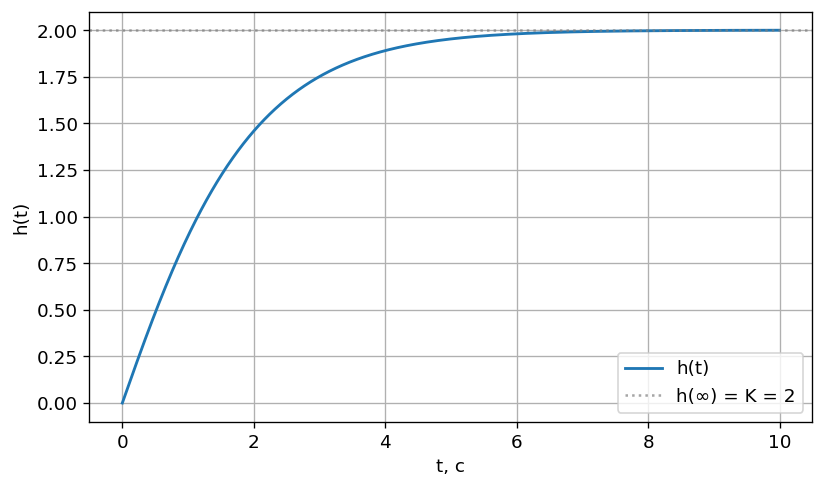

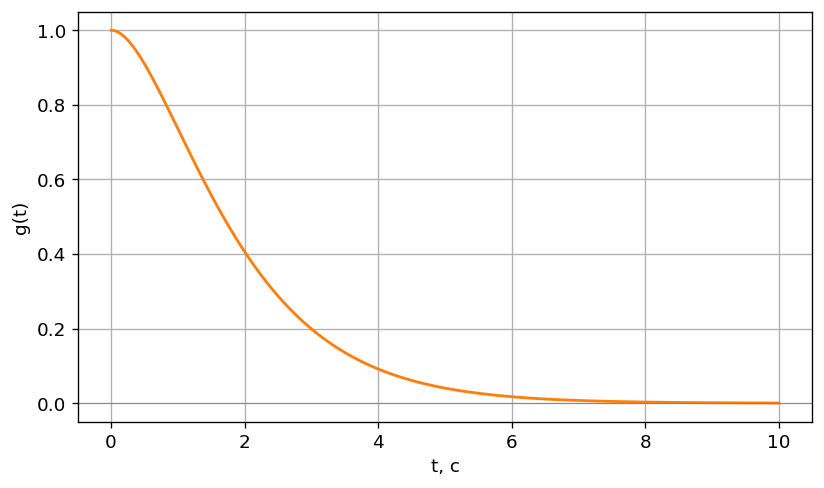

In [7]:
T_sim = np.linspace(0, 10, 1000)
t, h = ctrl.step_response(W, T=T_sim)
h_inf = float(h[-1])
h_max = float(np.max(h))
overshoot = (h_max - h_inf) / h_inf * 100
# время регулирования (5%)
band = 0.05 * abs(h_inf)
idx = np.where(np.abs(h - h_inf) > band)[0]
t_reg = t[idx[-1]] if len(idx) else 0.0
print(f"h(inf) = {h_inf:.4f}  (= K)")
print(f"h_max = {h_max:.4f},  перерегулирование = {overshoot:.2f} %")
print(f"время регулирования (5%) t_p = {t_reg:.3f} с")

plt.figure(figsize=(7, 4.2))
plt.plot(t, h, lw=1.7, color="C0", label="h(t)")
plt.axhline(h_inf, color="gray", ls=":", alpha=0.7, label=f"h(∞) = K = {h_inf:.0f}")
plt.xlabel("t, с"); plt.ylabel("h(t)"); plt.legend()
plt.tight_layout(); plt.savefig(FIG / "step.png"); plt.show()

t, g = ctrl.impulse_response(W, T=T_sim)
plt.figure(figsize=(7, 4.2))
plt.plot(t, g, lw=1.7, color="C1")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("t, с"); plt.ylabel("g(t)")
plt.tight_layout(); plt.savefig(FIG / "impulse.png"); plt.show()

## 6. Частотные характеристики (Боде) и запасы устойчивости

Запас по амплитуде GM = inf (бесконечный, нет частоты -180°)
Запас по фазе PM = 112.16 град на w_cp = 1.1414 рад/с


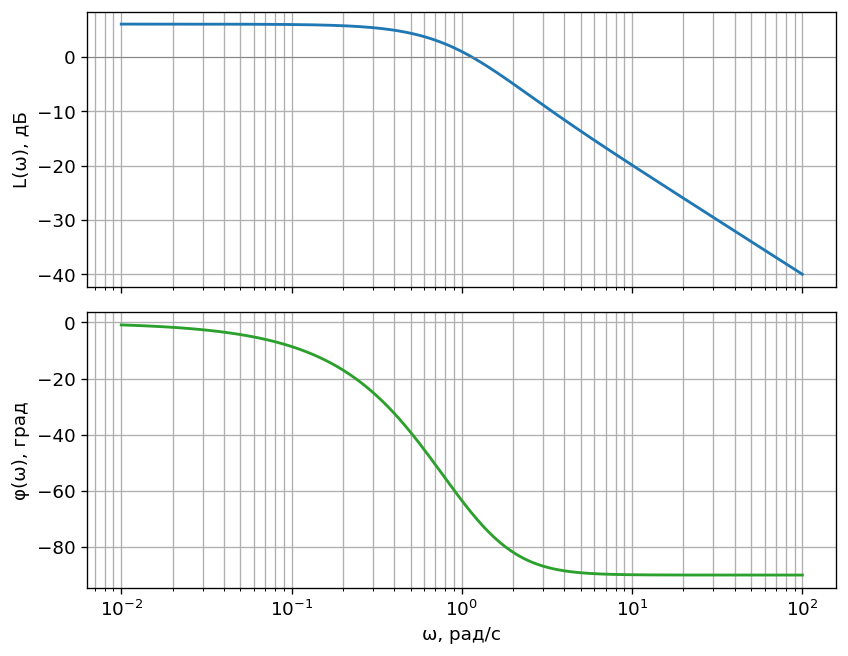

In [8]:
omega = np.logspace(-2, 2, 600)
mag, phase, omega = ctrl.frequency_response(W, omega)
mag_db = 20 * np.log10(mag)
phase_deg = np.rad2deg(phase)

gm, pm, wcg, wcp = ctrl.margin(W)
print(f"Запас по амплитуде GM = {gm} (бесконечный, нет частоты -180°)")
print(f"Запас по фазе PM = {pm:.2f} град на w_cp = {wcp:.4f} рад/с" if wcp is not None else "PM: система всегда устойчива")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.2, 5.6), sharex=True)
ax1.semilogx(omega, mag_db, color="C0", lw=1.7)
ax1.axhline(0, color="gray", lw=0.5)
ax1.set_ylabel("L(ω), дБ"); ax1.grid(True, which="both")
ax2.semilogx(omega, phase_deg, color="C2", lw=1.7)
ax2.set_ylabel("φ(ω), град"); ax2.set_xlabel("ω, рад/с"); ax2.grid(True, which="both")
plt.tight_layout(); plt.savefig(FIG / "bode.png"); plt.show()

## 7. Фазовый портрет автономной системы (u = 0)

eig(A) = -1 (кратное), матрица дефектна -> особая точка «устойчивый
вырожденный узел»: траектории входят в начало координат касательно
единственного собственного вектора.

Собственные векторы A:
 [[ 0.7071+0.j  0.7071-0.j]
 [-0.7071+0.j -0.7071-0.j]]


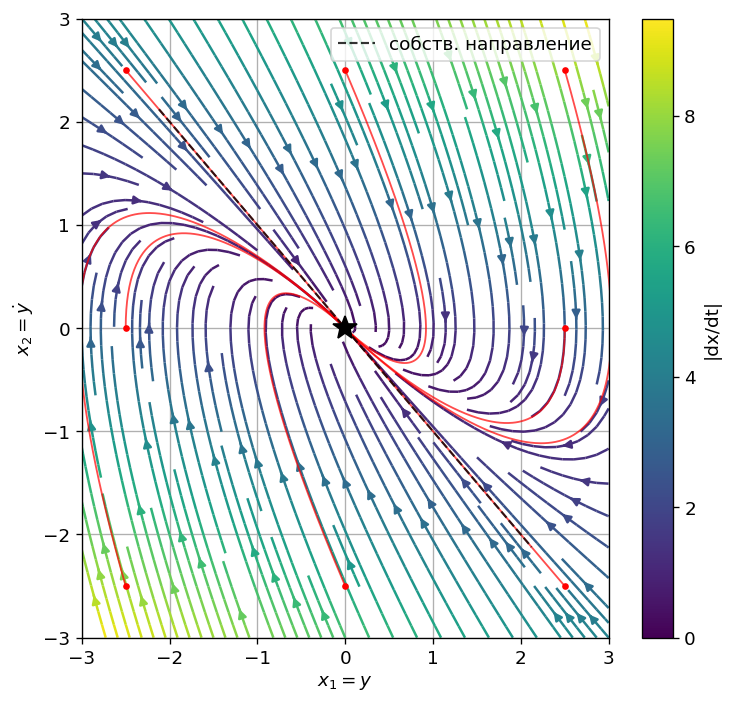

In [9]:
v = np.linalg.eig(A)[1]
print("Собственные векторы A:\n", v)

fig, ax = plt.subplots(figsize=(6.4, 6))
gx = np.linspace(-3, 3, 25)
X1, X2 = np.meshgrid(gx, gx)
dX1 = X2
dX2 = -a0 * X1 - a1 * X2
speed = np.sqrt(dX1**2 + dX2**2)
strm = ax.streamplot(X1, X2, dX1, dX2, density=1.5, color=speed, cmap="viridis")

def rhs(x, t):
    return [x[1], -a0 * x[0] - a1 * x[1]]

t_tr = np.linspace(0, 9, 700)
for x0 in [(2.5, 0), (-2.5, 0), (0, 2.5), (0, -2.5), (2.5, 2.5), (-2.5, -2.5), (2.5, -2.5), (-2.5, 2.5)]:
    sol = odeint(rhs, x0, t_tr)
    ax.plot(sol[:, 0], sol[:, 1], "r-", alpha=0.7, lw=1.1)
    ax.plot(*x0, "ro", ms=3)
# собственное направление
ev = v[:, 0].real
ev = ev / np.linalg.norm(ev)
ax.plot([-3*ev[0], 3*ev[0]], [-3*ev[1], 3*ev[1]], "k--", lw=1.3, alpha=0.8, label="собств. направление")
ax.plot(0, 0, "k*", ms=15)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_xlabel(r"$x_1 = y$"); ax.set_ylabel(r"$x_2 = \dot y$")
ax.legend(loc="upper right")
plt.colorbar(strm.lines, ax=ax, label="|dx/dt|")
plt.tight_layout(); plt.savefig(FIG / "phase_portrait.png"); plt.show()

## 8. Дискретизация (T = 0,1 с): ZOH и Тастин

In [10]:
T = 0.1
Ad, Bd, Cd, Dd, _ = signal.cont2discrete((A, B, C, D), T, method="zoh")
Adt, Bdt, Cdt, Ddt, _ = signal.cont2discrete((A, B, C, D), T, method="bilinear")
print("ZOH:  Ad =\n", Ad, "\n Bd =", Bd.ravel(), " Dd =", Dd.ravel())
print("Тастин: Ad =\n", Adt, "\n Bd =", Bdt.ravel(), " Dd =", Ddt.ravel())

pz = np.linalg.eigvals(Ad)
pt = np.linalg.eigvals(Adt)
print("Полюсы ZOH z =", pz, " |z| =", np.abs(pz))
print("Полюсы Тастин z =", pt, " |z| =", np.abs(pt))
print("Теоретически z = e^{sT} = e^{-0.1} =", np.exp(-0.1))

ZOH:  Ad =
 [[ 0.9953  0.0905]
 [-0.0905  0.8144]] 
 Bd = [0.0047 0.0905]  Dd = [0.]
Тастин: Ad =
 [[ 0.9955  0.0907]
 [-0.0907  0.8141]] 
 Bd = [0.0045 0.0907]  Dd = [0.0499]
Полюсы ZOH z = [0.9048+0.j 0.9048-0.j]  |z| = [0.9048 0.9048]
Полюсы Тастин z = [0.9048 0.9048]  |z| = [0.9048 0.9048]
Теоретически z = e^{sT} = e^{-0.1} = 0.9048374180359595


## 9. Полюсы на z-плоскости и сравнение переходных процессов

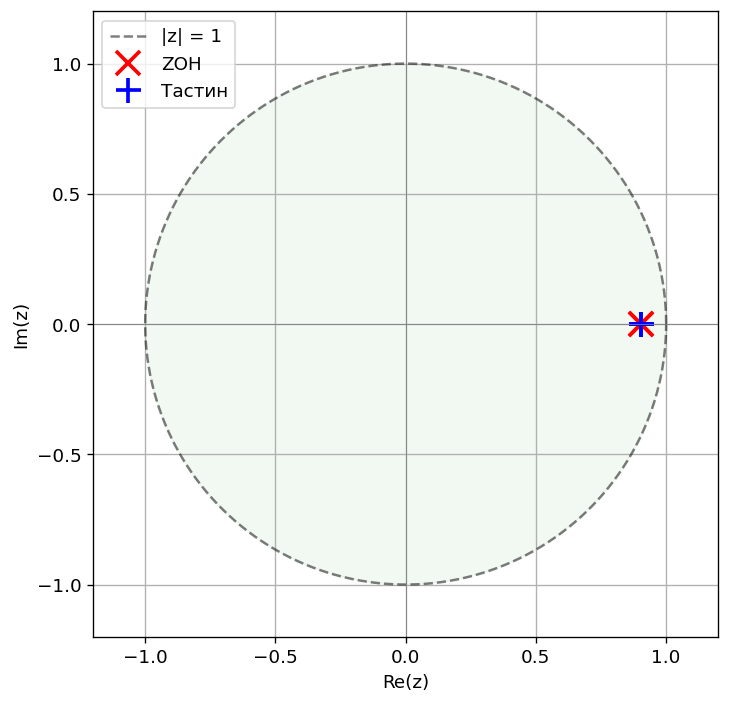

Установившиеся: непр. 1.9995, ZOH 1.9995, Тастин 1.9995


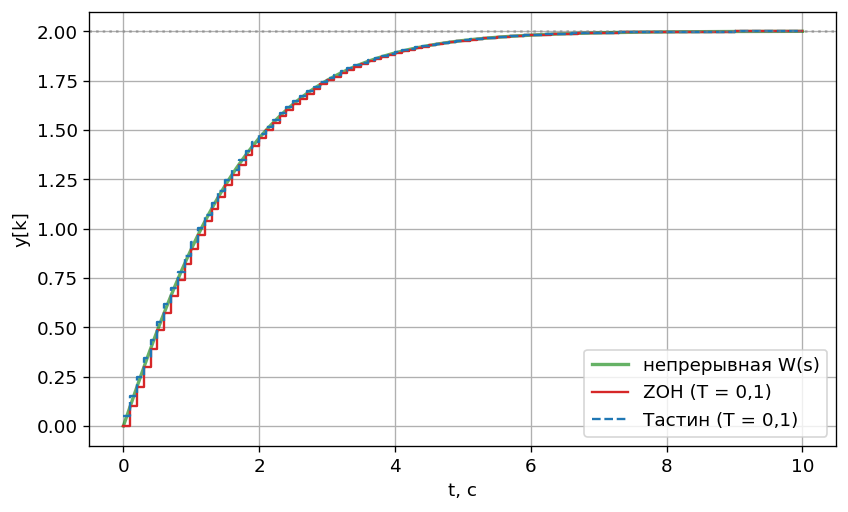

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
th = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(th), np.sin(th), "k--", alpha=0.5, label="|z| = 1")
ax.fill(np.cos(th), np.sin(th), alpha=0.05, color="green")
ax.plot(pz.real, pz.imag, "rx", ms=14, mew=2.2, label="ZOH")
ax.plot(pt.real, pt.imag, "b+", ms=15, mew=2.2, label="Тастин")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal"); ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_xlabel("Re(z)"); ax.set_ylabel("Im(z)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(FIG / "z_poles.png"); plt.show()

sys_z = ctrl.ss(Ad, Bd, Cd, Dd, dt=T)
sys_t = ctrl.ss(Adt, Bdt, Cdt, Ddt, dt=T)
t_d = np.arange(0, 10 + T, T)
tz, yz = ctrl.step_response(sys_z, T=t_d)
tt, yt = ctrl.step_response(sys_t, T=t_d)
tc, yc = ctrl.step_response(W, T=np.linspace(0, 10, 1000))
print(f"Установившиеся: непр. {yc[-1]:.4f}, ZOH {yz[-1]:.4f}, Тастин {yt[-1]:.4f}")

plt.figure(figsize=(7.2, 4.4))
plt.plot(tc, yc, "g-", alpha=0.6, lw=2, label="непрерывная W(s)")
plt.step(tz, yz, where="post", color="C3", lw=1.4, label="ZOH (T = 0,1)")
plt.step(tt, yt, where="post", color="C0", lw=1.4, ls="--", label="Тастин (T = 0,1)")
plt.axhline(yc[-1], color="gray", ls=":", alpha=0.6)
plt.xlabel("t, с"); plt.ylabel("y[k]"); plt.legend()
plt.tight_layout(); plt.savefig(FIG / "discrete_step.png"); plt.show()